In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [132]:
method_list= ["AVAR", "KL", "risk_neutral", "DCA_l2", "DCA_l1"]
# method_list = ["KL"]
S_list = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
# S_list = [20,40]
batch_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# radius_list = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
# radius_list = [0.5, 1.0, 1.5, 2.0, 2.5]
# radius_list = [1.0,4.0,7.0, 10.0, 13.0, 16.0]
radius_list = dict()
radius_list["risk_neutral"] = [0]
radius_list["DCA_l2"] = [3.8]
radius_list["DCA_l1"] = [7.0]
# radius_list["KL"] = [0.9]
radius_list["AVAR"] = [0.7, 0.8, 0.9]
radius_list["KL"] = [0.7, 0.8, 0.9]
force_list = [1.0, 2.0, 3.0]
# force_list = [1.0]
Gamma_list = [-1.0]
gap = 0.1

In [133]:
df = dict()
combos = []
for method in method_list:
    for S in S_list:
        for batch in batch_list:
            for radius in radius_list[method]:
                for force in force_list:
                    for Gamma in Gamma_list:
                        csv_path = f"{method}/IEEE54_{S}_{batch}_{force}_{gap}_{radius}_{Gamma}.csv"
                        t = 3600
                        if pd.io.common.file_exists(csv_path):
                            df_csv = pd.read_csv(csv_path, sep=",", encoding="utf-8")
                            df[(method, S, batch, radius, force, Gamma)] = df_csv
                            t = float(df[(method, S, batch, radius, force, Gamma)].iloc[4,1])
                        else:
                            print(f"Fichier introuvable : {csv_path}")
                            combos.append((method, S, batch, radius, force, Gamma))
                        if t >= 3550:
                            print(f"Timeout : {csv_path}")
                            combos.append((method, S, batch, radius, force, Gamma))

time_dict = dict()
oos_dict = dict()
for method in method_list:
    for S in S_list:
        for batch in batch_list:
            for radius in radius_list[method]:
                for force in force_list:
                    for Gamma in Gamma_list:
                        time_dict[(method, S, batch, radius, force, Gamma)] = float(df[(method, S, batch, radius, force, Gamma)].iloc[4,1])
                        oos_dict[(method, S, batch, radius, force, Gamma)] = float(df[(method, S, batch, radius, force, Gamma)].iloc[9,1])

oos_average = dict()
time_average = dict()
for method in method_list:
    for force in force_list:
        for S in S_list:
            for radius in radius_list[method]:
                for Gamma in Gamma_list:
                    oos_average[(method, S, radius, force, Gamma)] = np.mean([oos_dict[(method, S, batch, radius, force, Gamma)] for batch in batch_list])
                    time_average[(method, S, radius, force, Gamma)] = np.mean([time_dict[(method, S, batch, radius, force, Gamma)] for batch in batch_list])

Timeout : AVAR/IEEE54_80_7_1.0_0.1_0.8_-1.0.csv
Timeout : AVAR/IEEE54_90_6_1.0_0.1_0.7_-1.0.csv
Timeout : AVAR/IEEE54_100_8_1.0_0.1_0.7_-1.0.csv
Timeout : KL/IEEE54_40_6_1.0_0.1_0.8_-1.0.csv
Timeout : KL/IEEE54_50_10_1.0_0.1_0.7_-1.0.csv
Timeout : KL/IEEE54_60_1_1.0_0.1_0.9_-1.0.csv
Timeout : KL/IEEE54_60_2_1.0_0.1_0.7_-1.0.csv
Timeout : KL/IEEE54_60_3_1.0_0.1_0.8_-1.0.csv
Timeout : KL/IEEE54_60_4_1.0_0.1_0.7_-1.0.csv
Timeout : KL/IEEE54_60_4_1.0_0.1_0.9_-1.0.csv
Timeout : KL/IEEE54_60_7_1.0_0.1_0.7_-1.0.csv
Timeout : KL/IEEE54_60_7_1.0_0.1_0.9_-1.0.csv
Timeout : KL/IEEE54_60_8_1.0_0.1_0.7_-1.0.csv
Timeout : KL/IEEE54_60_8_1.0_0.1_0.8_-1.0.csv
Timeout : KL/IEEE54_60_8_1.0_0.1_0.9_-1.0.csv
Timeout : KL/IEEE54_70_1_1.0_0.1_0.7_-1.0.csv
Timeout : KL/IEEE54_70_4_1.0_0.1_0.8_-1.0.csv
Timeout : KL/IEEE54_70_5_1.0_0.1_0.7_-1.0.csv
Timeout : KL/IEEE54_70_5_1.0_0.1_0.8_-1.0.csv
Timeout : KL/IEEE54_70_5_1.0_0.1_0.9_-1.0.csv
Timeout : KL/IEEE54_70_6_1.0_0.1_0.8_-1.0.csv
Timeout : KL/IEEE54_70_7_1

In [39]:
len(combos)

116

In [134]:
Gamma_RO = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
method_RO = ["RO_DCA", "Moment_DCA"]
df_RO = dict()
for method in method_RO:
    for force in force_list:
        for Gamma in Gamma_RO:
            csv_path = f"{method}/IEEE54_0_0_{force}_{gap}_0.0_{Gamma}.csv"
            if pd.io.common.file_exists(csv_path):
                df_csv = pd.read_csv(csv_path, sep=",", encoding="utf-8")
                df_RO[(method, force, Gamma)] = df_csv
            else:
                print(f"Fichier introuvable : {csv_path}")

df_RO_time_dict = dict()
df_RO_oos_dict = dict()
for method in method_RO:
    for force in force_list:
        for Gamma in Gamma_RO:
            df_RO_time_dict[(method, force, Gamma)] = float(df_RO[(method, force, Gamma)].iloc[4,1])
            df_RO_oos_dict[(method, force, Gamma)] = float(df_RO[(method, force, Gamma)].iloc[9,1])

df_RO_time = dict()
df_RO_oos = dict()
for method in method_RO:
    for force in force_list:
            index = np.argmin([df_RO_oos_dict[(method, force, Gamma)] for Gamma in Gamma_RO])
            df_RO_time[(method, force)] = df_RO_time_dict[(method, force, Gamma_RO[index])]
            df_RO_oos[(method, force)] = df_RO_oos_dict[(method, force, Gamma_RO[index])]

In [135]:
colors_method = dict()
colors_method["risk_neutral"] = "black"
colors_method["DCA_l2"] = "red"
colors_method["DCA_l1"] = "blue"
colors_method["RO_DCA"] = "green"
colors_method["Moment_DCA"] = "teal"
colors_method["KL"] = "purple"
colors_method["AVAR"] = "orange"

linestyles = dict()
linestyles["risk_neutral", 0] = '-'
linestyles["DCA_l2", 3.8] = '--'
linestyles["DCA_l1", 7.0] = '--'
linestyles["RO_DCA"] = '--'
linestyles["Moment_DCA"] = '-.'
linestyles["AVAR", 0.7] = '-'
linestyles["AVAR", 0.8] = '--'
linestyles["AVAR", 0.9] = ':'
linestyles["KL", 0.7] = '-'
linestyles["KL", 0.8] = '--'
linestyles["KL", 0.9] = ':'

labels = dict()
labels["risk_neutral", 0] = "Risk Neutral"
labels["DCA_l2", 3.8] = "DRO L2 (DCA)"
labels["DCA_l1", 7.0] = "DRO L1 (DCA)"
labels["RO_DCA"] = "RO (DCA)"
labels["Moment_DCA"] = "Moment (DCA)"
labels["AVAR", 0.7] = "AVAR 0.7"
labels["AVAR", 0.8] = "AVAR 0.8"
labels["AVAR", 0.9] = "AVAR 0.9"
labels["KL", 0.7] = "KL 0.7"
labels["KL", 0.8] = "KL 0.8"
labels["KL", 0.9] = "KL 0.9"

sizefont=30

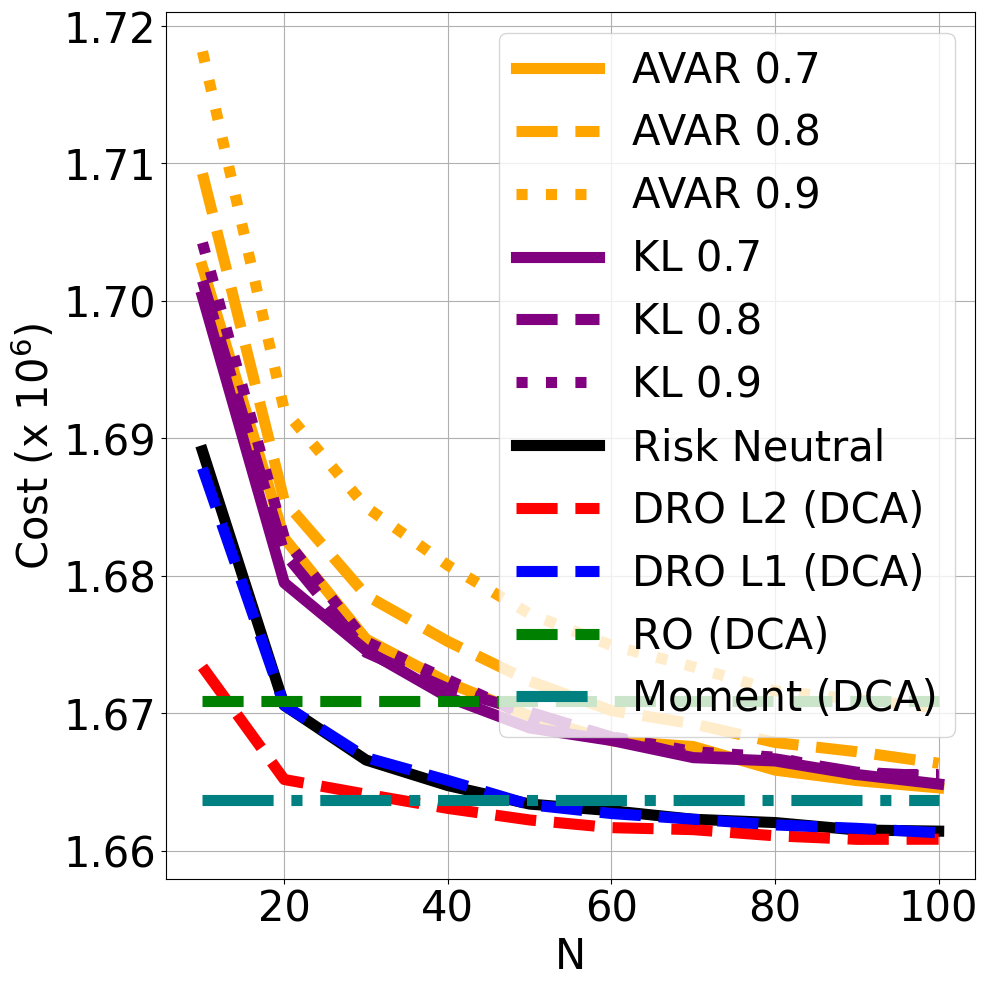

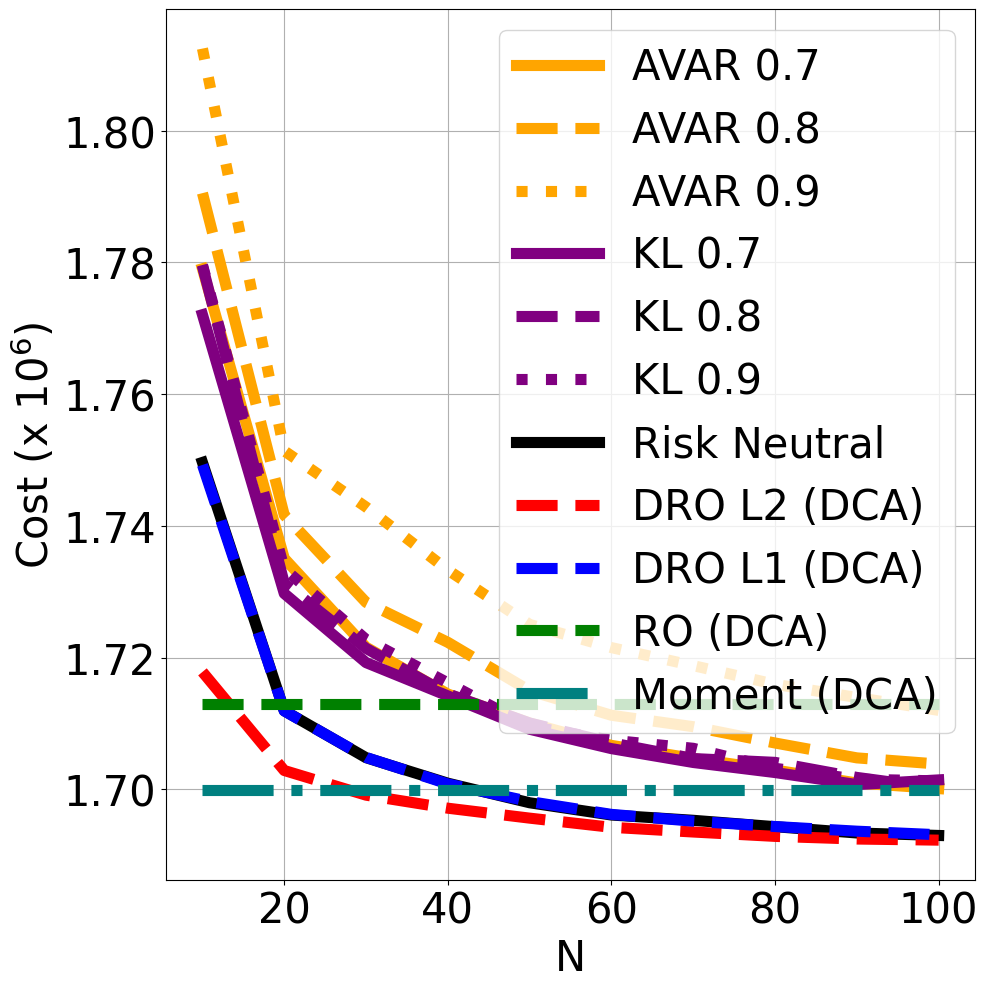

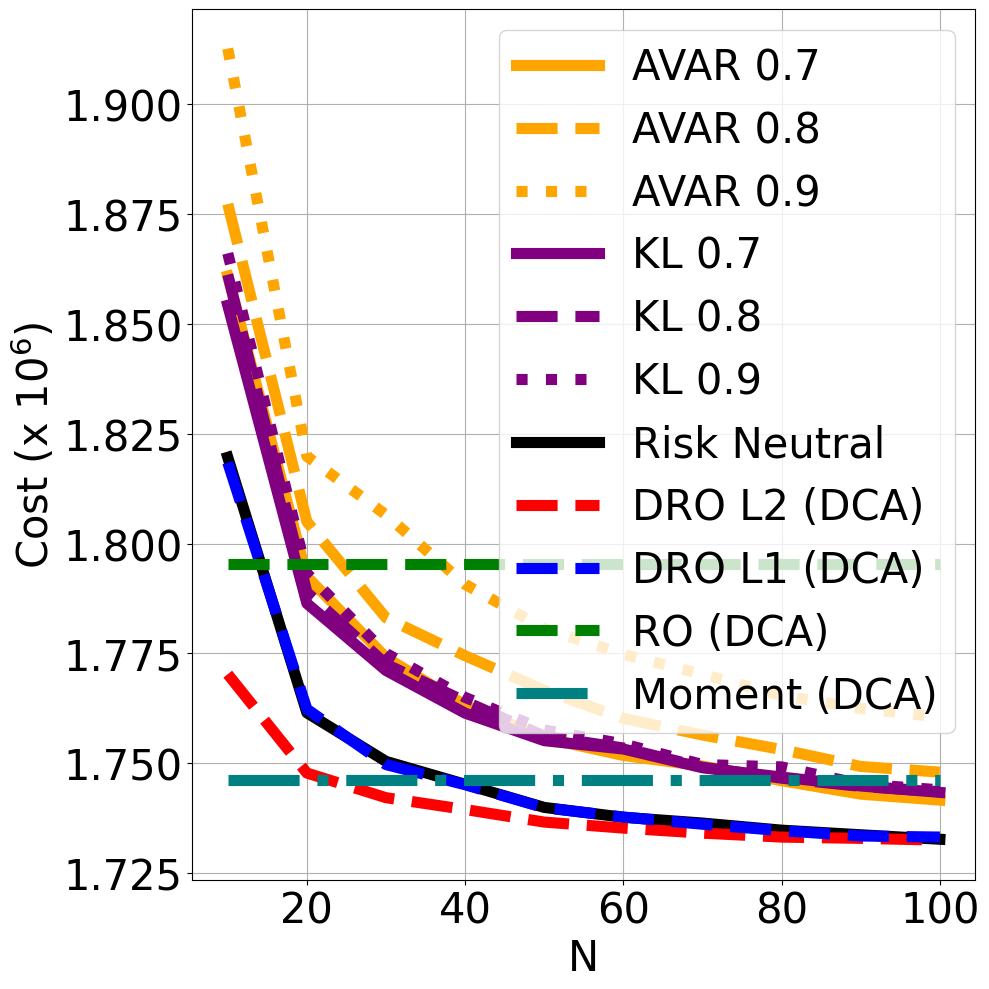

In [136]:
for force in force_list:
    plt.figure(figsize=(10, 10))
    for method in method_list:
        for r in radius_list[method]:
            Gamma = Gamma_list[0]
            plt.plot(
                S_list,
                [oos_average[(method, S, r, force, Gamma)] / 1e6 for S in S_list],
                linestyle=linestyles[method, r],
                label=f"{labels[method, r]}",
                color=colors_method[method],
                linewidth=8
            )
    for method in method_RO:
        plt.plot(
            S_list,
            [df_RO_oos[(method, force)] / 1e6 for S in S_list],
            linestyle=linestyles[method],
            label=f"{labels[method]}",
            color=colors_method[method],
            linewidth=8
        )

    plt.xlabel("N", fontsize=sizefont)
    plt.ylabel("Cost (x $10^6$)", fontsize=sizefont)
    plt.tick_params(axis='both', labelsize=sizefont)
    plt.gca().yaxis.offsetText.set_fontsize(sizefont)
    plt.legend(fontsize=sizefont, loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    # plt.savefig(f"OOS_comparison_{round(force)}.pdf") 

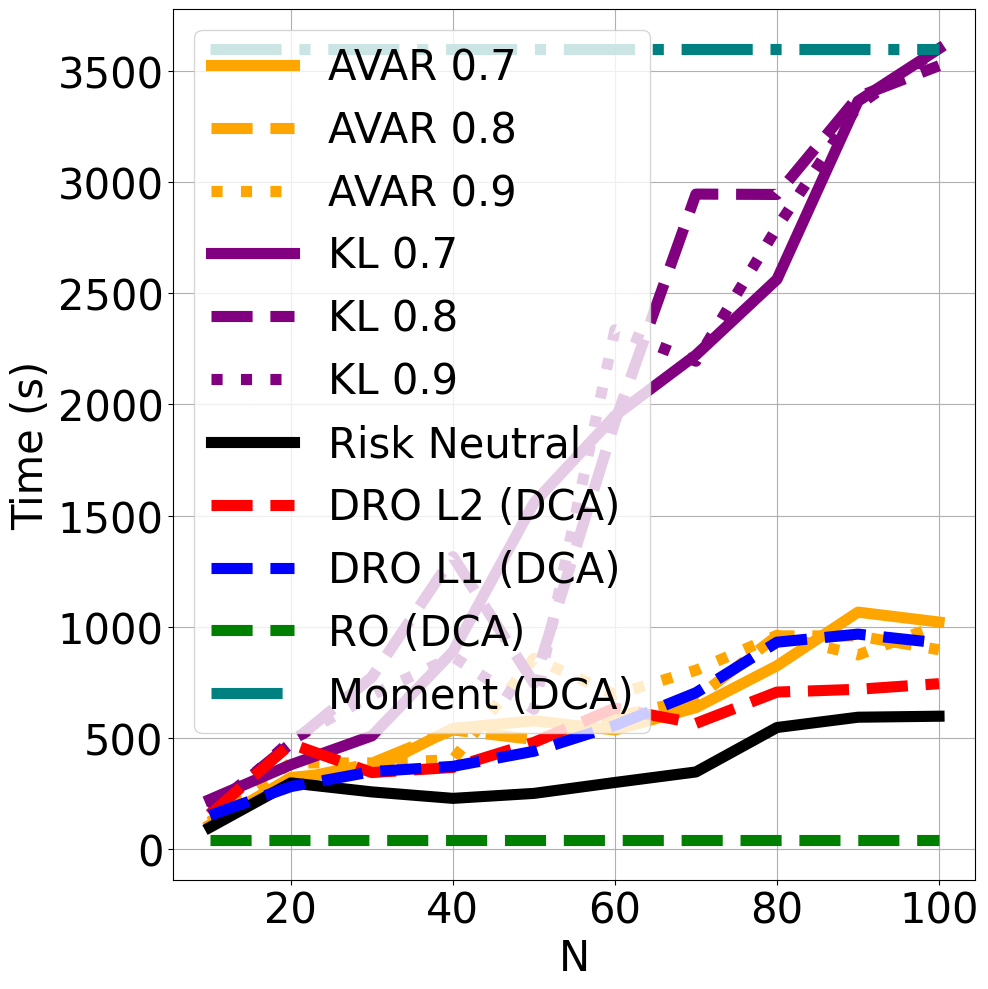

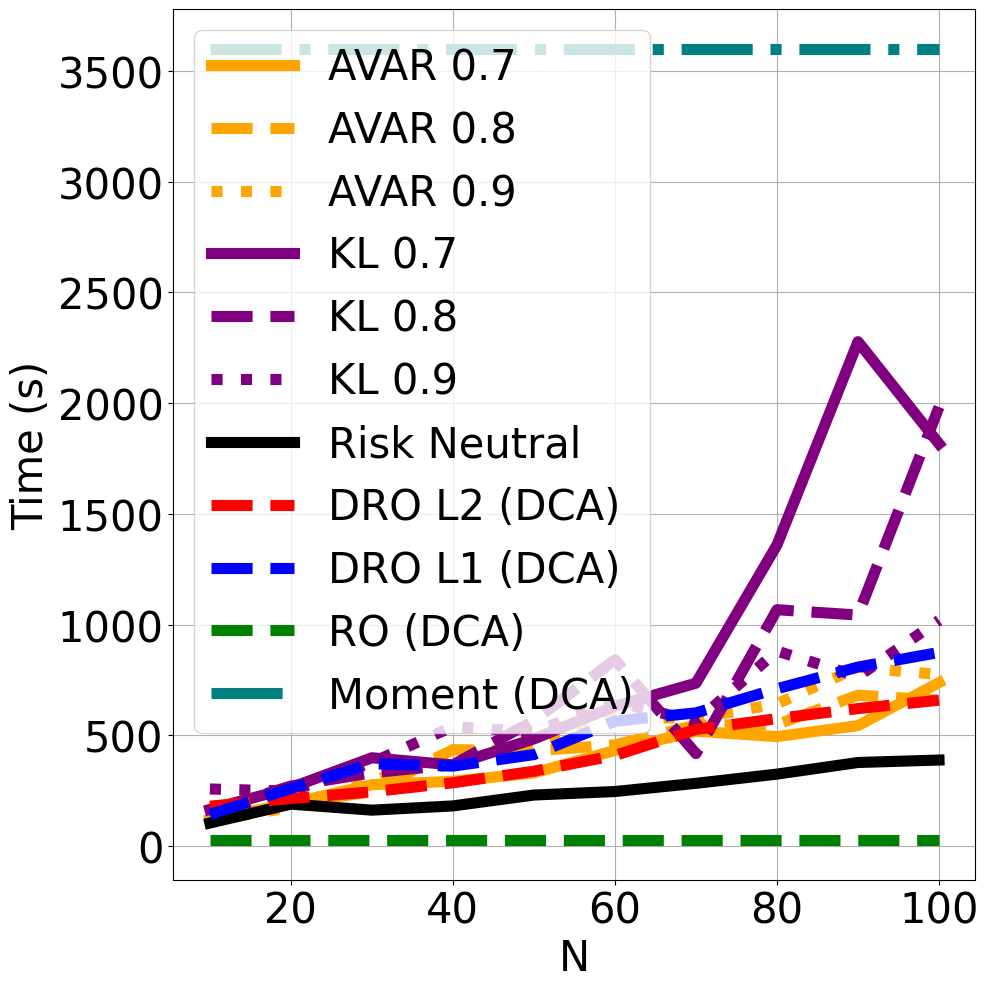

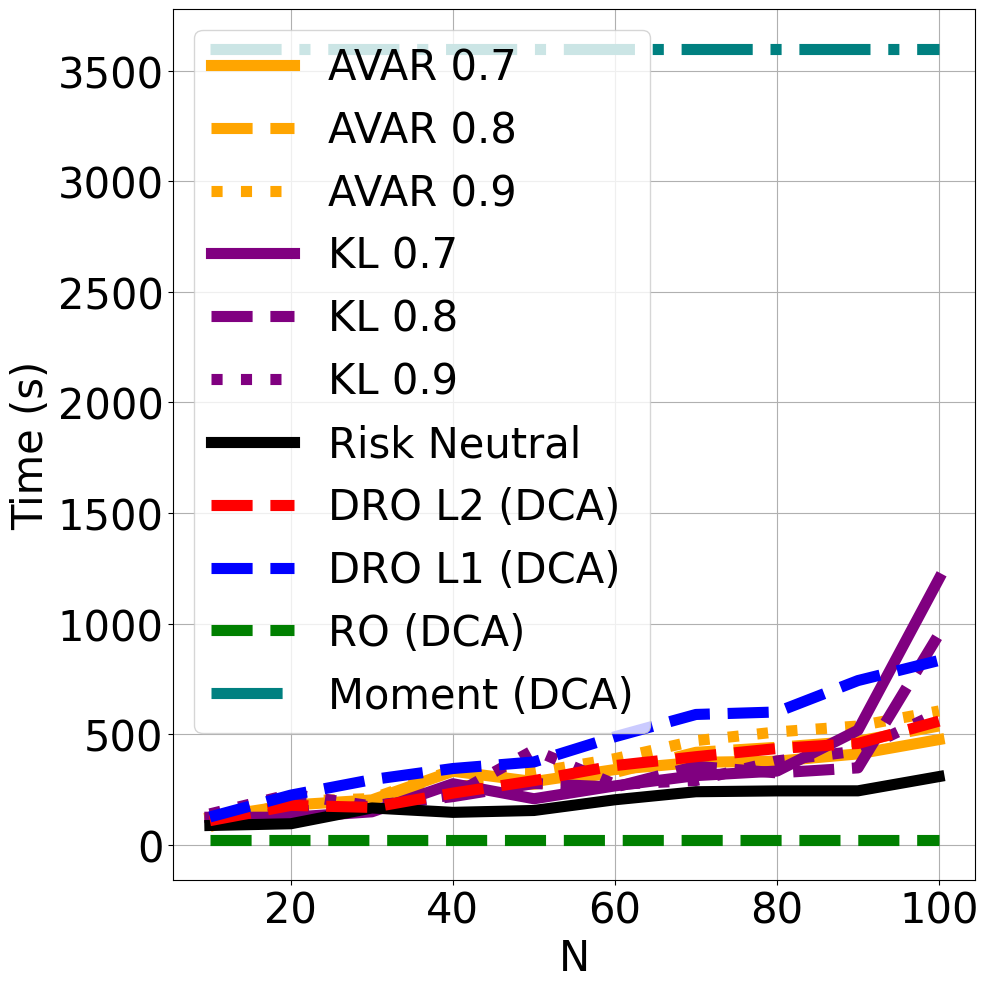

In [137]:
for force in force_list:
    plt.figure(figsize=(10, 10))
    for method in method_list:
        for r in radius_list[method]:
            Gamma = Gamma_list[0]
            plt.plot(
                S_list,
                [time_average[(method, S, r, force, Gamma)] for S in S_list],
                linestyle=linestyles[method, r],
                label=f"{labels[method, r]}",
                color=colors_method[method],
                linewidth=8
            )
    
    for method in method_RO:
        plt.plot(
            S_list,
            [df_RO_time[(method, force)] for S in S_list],
            linestyle=linestyles[method],
            label=f"{labels[method]}",
            color=colors_method[method],
            linewidth=8
        )

    plt.xlabel("N", fontsize=sizefont)
    plt.ylabel("Time (s)", fontsize=sizefont)
    plt.tick_params(axis='both', labelsize=sizefont)
    plt.gca().yaxis.offsetText.set_fontsize(sizefont)
    plt.legend(fontsize=sizefont, loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    # plt.savefig(f"time_comparison_{round(force)}.pdf") 

In [122]:
method_list= ["DCA_l2", "Grb_l2", "DCA_l1", "Grb_l1"]
S_list = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
batch_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
radius_list = dict()
radius_list["DCA_l2"] = [3.3]
radius_list["DCA_l2_budget"] = [2.0]
radius_list["Grb_l2"] = [1.5]
radius_list["DCA_l1"] = [7.0]
radius_list["Grb_l1"] = [7.0]
force_list = [1.0]
# force_list = [1.0]
Gamma_list = dict()
Gamma_list["DCA_l2"] = [-1.0]
Gamma_list["DCA_l2_budget"] = [3.0]
Gamma_list["Grb_l2"] = [-1.0]
Gamma_list["DCA_l1"] = [-1.0]
Gamma_list["Grb_l1"] = [-1.0]
gap = 0.1

In [123]:
df = dict()
combos = []
for method in method_list:
    for S in S_list:
        for batch in batch_list:
            for radius in radius_list[method]:
                for force in force_list:
                    for Gamma in Gamma_list[method]:
                        csv_path = f"{method}/IEEE3_{S}_{batch}_{force}_{gap}_{radius}_{Gamma}.csv"
                        t = 1800
                        if pd.io.common.file_exists(csv_path):
                            df_csv = pd.read_csv(csv_path, sep=",", encoding="utf-8")
                            df[(method, S, batch, radius, force, Gamma)] = df_csv
                            t = float(df[(method, S, batch, radius, force, Gamma)].iloc[4,1])
                        else:
                            print(f"Fichier introuvable : {csv_path}")
                            combos.append((method, S, batch, radius, force, Gamma))
                        if t >= 1750:
                            print(f"Timeout : {csv_path} {t}")
                            combos.append((method, S, batch, radius, force, Gamma))

time_dict = dict()
oos_dict = dict()
for method in method_list:
    for S in S_list:
        for batch in batch_list:
            for radius in radius_list[method]:
                for force in force_list:
                    for Gamma in Gamma_list[method]:
                        time_dict[(method, S, batch, radius, force, Gamma)] = float(df[(method, S, batch, radius, force, Gamma)].iloc[4,1])
                        oos_dict[(method, S, batch, radius, force, Gamma)] = float(df[(method, S, batch, radius, force, Gamma)].iloc[9,1])

oos_average = dict()
time_average = dict()
for method in method_list:
    for force in force_list:
        for S in S_list:
            for radius in radius_list[method]:
                for Gamma in Gamma_list[method]:
                    oos_average[(method, S, radius, force, Gamma)] = np.mean([oos_dict[(method, S, batch, radius, force, Gamma)] for batch in batch_list])
                    time_average[(method, S, radius, force, Gamma)] = np.mean([time_dict[(method, S, batch, radius, force, Gamma)] for batch in batch_list])

In [124]:
Gamma_RO = [round(0.5+0.1*i, 2) for i in range(21)]
method_RO = ["RO_DCA", "RO_MILP"]
df_RO = dict()
for method in method_RO:
    for force in force_list:
        for Gamma in Gamma_RO:
            csv_path = f"{method}/IEEE3_0_0_{force}_{gap}_0.0_{Gamma}.csv"
            if pd.io.common.file_exists(csv_path):
                df_csv = pd.read_csv(csv_path, sep=",", encoding="utf-8")
                df_RO[(method, force, Gamma)] = df_csv
            else:
                print(f"Fichier introuvable : {csv_path}")

df_RO_time_dict = dict()
df_RO_oos_dict = dict()
for method in method_RO:
    for force in force_list:
        for Gamma in Gamma_RO:
            df_RO_time_dict[(method, force, Gamma)] = float(df_RO[(method, force, Gamma)].iloc[4,1])
            df_RO_oos_dict[(method, force, Gamma)] = float(df_RO[(method, force, Gamma)].iloc[9,1])

df_RO_time = dict()
df_RO_oos = dict()
for method in method_RO:
    for force in force_list:
            index = np.argmin([df_RO_oos_dict[(method, force, Gamma)] for Gamma in Gamma_RO])
            df_RO_time[(method, force)] = df_RO_time_dict[(method, force, Gamma_RO[index])]
            df_RO_oos[(method, force)] = df_RO_oos_dict[(method, force, Gamma_RO[index])]

In [127]:
colors_method = dict()
colors_method["DCA_l2"] = "red"
colors_method["DCA_l1"] = "blue"
colors_method["Grb_l2"] = "red"
colors_method["Grb_l1"] = "blue"
colors_method["DCA_l2_budget"] = "purple"
colors_method["RO_DCA"] = "green"
colors_method["RO_MILP"] = "green"
colors_method["Moment_DCA"] = "teal"

linestyles = dict()
linestyles["DCA_l2", 3.3] = '--'
linestyles["DCA_l1", 7.0] = '--'
linestyles["Grb_l2", 1.5] = '-'
linestyles["Grb_l1", 7.0] = '-'
linestyles["DCA_l2_budget", 2.0] = '-'
linestyles["RO_DCA"] = '--'
linestyles["RO_MILP"] = '-'
linestyles["Moment_DCA"] = '-.'

labels = dict()
labels["DCA_l2", 3.3] = "DRO L2 (DCA)"
labels["DCA_l1", 7.0] = "DRO L1 (DCA)"
labels["Grb_l2", 1.5] = "DRO L2 (GRB)"
labels["Grb_l1", 7.0] = "DRO L1 (GRB)"
labels["DCA_l2_budget", 2.0] = "DRO L2 Budget (DCA)"
labels["RO_DCA"] = "RO (DCA)"
labels["RO_MILP"] = "RO (MILP)"
labels["Moment_DCA"] = "Moment (DCA)"

sizefont=30

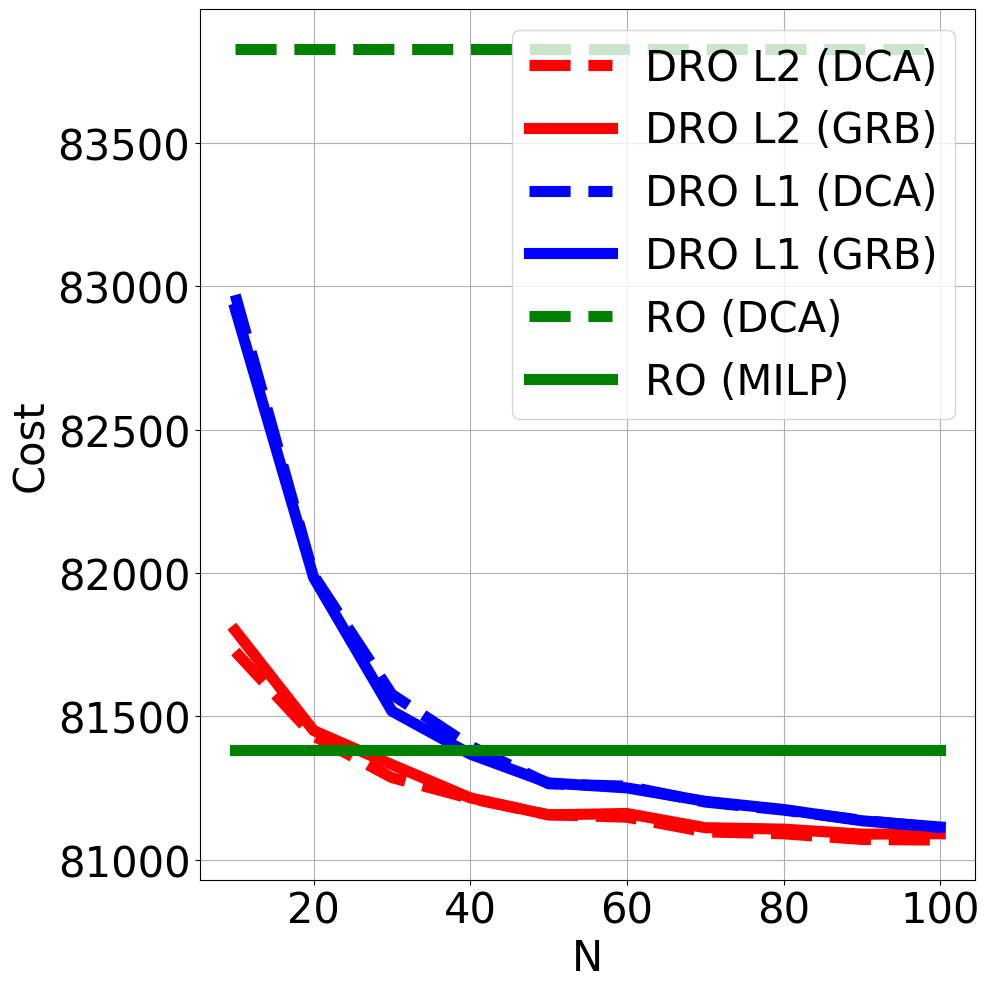

In [130]:
for force in force_list:
    plt.figure(figsize=(10, 10))
    for method in method_list:
        for r in radius_list[method]:
            Gamma = Gamma_list[method][0]
            plt.plot(
                S_list,
                [oos_average[(method, S, r, force, Gamma)] for S in S_list],
                linestyle=linestyles[method, r],
                label=f"{labels[method, r]}",
                color=colors_method[method],
                linewidth=8
            )

    for method in method_RO:
        plt.plot(
            S_list,
            [df_RO_oos[(method, force)] for S in S_list],
            linestyle=linestyles[method],
            label=f"{labels[method]}",
            color=colors_method[method],
            linewidth=8
        )

    plt.xlabel("N", fontsize=sizefont)
    plt.ylabel("Cost", fontsize=sizefont)
    plt.tick_params(axis='both', labelsize=sizefont)
    plt.gca().yaxis.offsetText.set_fontsize(sizefont)
    plt.legend(fontsize=sizefont, loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    # plt.savefig(f"OOS_DCA.pdf") 

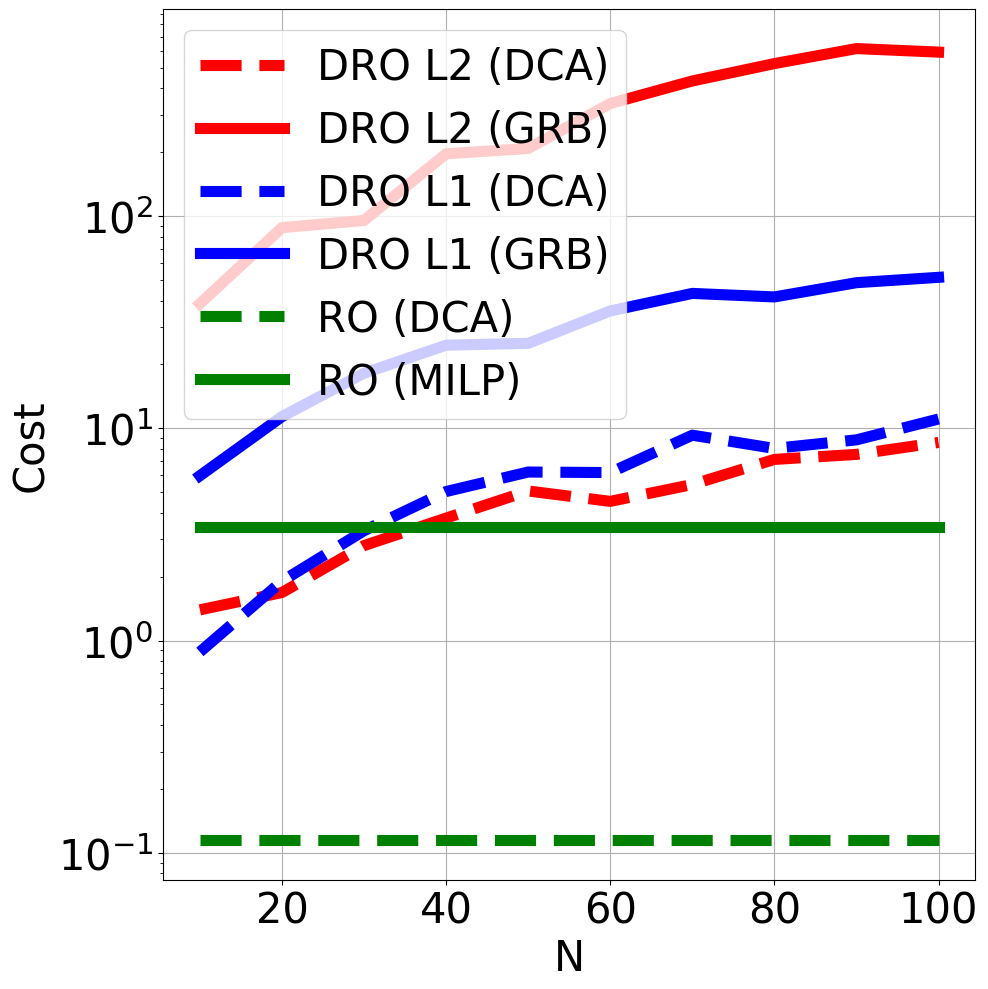

In [131]:
for force in force_list:
    plt.figure(figsize=(10, 10))
    for method in method_list:
        for r in radius_list[method]:
            Gamma = Gamma_list[method][0]
            plt.plot(
                S_list,
                [time_average[(method, S, r, force, Gamma)] for S in S_list],
                linestyle=linestyles[method, r],
                label=f"{labels[method, r]}",
                color=colors_method[method],
                linewidth=8
            )

    for method in method_RO:
        plt.plot(
            S_list,
            [df_RO_time[(method, force)] for S in S_list],
            linestyle=linestyles[method],
            label=f"{labels[method]}",
            color=colors_method[method],
            linewidth=8
        )

    plt.xlabel("N", fontsize=sizefont)
    plt.ylabel("Cost", fontsize=sizefont)
    plt.yscale('log')
    plt.tick_params(axis='both', labelsize=sizefont)
    plt.gca().yaxis.offsetText.set_fontsize(sizefont)
    plt.legend(fontsize=sizefont, loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    # plt.savefig(f"time_DCA.pdf") 